In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "diyasnair",\r\n  "key": "KGAT_dd6665e1d80f2842a799d7bdaf080302"\r\n}\r\n\r\n'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:10<00:00, 15.7MB/s]



In [6]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [7]:
import os

os.listdir("Testing/meningioma")

['Te-me_261.jpg',
 'Te-aug-me_77.jpg',
 'Te-me_238.jpg',
 'Te-me_235.jpg',
 'Te-me_75.jpg',
 'Te-me_194.jpg',
 'Te-me_52.jpg',
 'Te-me_264.jpg',
 'Te-me_158.jpg',
 'Te-aug-me_34.jpg',
 'Te-me_62.jpg',
 'Te-me_181.jpg',
 'Te-me_31.jpg',
 'Te-me_92.jpg',
 'Te-aug-me_66.jpg',
 'Te-me_16.jpg',
 'Te-me_190.jpg',
 'Te-me_260.jpg',
 'Te-me_63.jpg',
 'Te-me_14.jpg',
 'Te-me_121.jpg',
 'Te-aug-me_43.jpg',
 'Te-me_68.jpg',
 'Te-me_57.jpg',
 'Te-aug-me_102.jpg',
 'Te-me_223.jpg',
 'Te-me_157.jpg',
 'Te-me_105.jpg',
 'Te-me_1.jpg',
 'Te-me_82.jpg',
 'Te-me_265.jpg',
 'Te-me_116.jpg',
 'Te-aug-me_96.jpg',
 'Te-aug-me_5.jpg',
 'Te-me_131.jpg',
 'Te-aug-me_6.jpg',
 'Te-me_118.jpg',
 'Te-me_4.jpg',
 'Te-me_198.jpg',
 'Te-me_240.jpg',
 'Te-me_65.jpg',
 'Te-aug-me_19.jpg',
 'Te-me_127.jpg',
 'Te-aug-me_21.jpg',
 'Te-aug-me_83.jpg',
 'Te-me_239.jpg',
 'Te-me_282.jpg',
 'Te-aug-me_57.jpg',
 'Te-me_232.jpg',
 'Te-me_15.jpg',
 'Te-me_237.jpg',
 'Te-me_286.jpg',
 'Te-me_85.jpg',
 'Te-aug-me_7.jpg',
 'Te-aug-

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    'Training/',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    'Testing/',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Clinical Classes: {class_names}")



Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Clinical Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
# Optimize data distribution across GPU threads
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


base_model = keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze medical-agnostic feature layers

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = keras.Model(inputs, outputs)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
print("\nInitializing Clinical Feature Extraction")
history = model.fit(train_ds, validation_data=val_ds, epochs=15)


Initializing Clinical Feature Extraction
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8995 - loss: 0.2733 - val_accuracy: 0.8637 - val_loss: 0.4014
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8998 - loss: 0.2658 - val_accuracy: 0.8781 - val_loss: 0.3961
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9023 - loss: 0.2691 - val_accuracy: 0.8756 - val_loss: 0.3851
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9029 - loss: 0.2595 - val_accuracy: 0.8694 - val_loss: 0.4194
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9004 - loss: 0.2612 - val_accuracy: 0.8719 - val_loss: 0.4146
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9036 - loss: 0.2590 - val_accuracy: 0.8794 - val_loss: 0.3986
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9050 - loss: 0.2583 - val_accuracy: 0.8806 - val_loss: 0.3913
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/

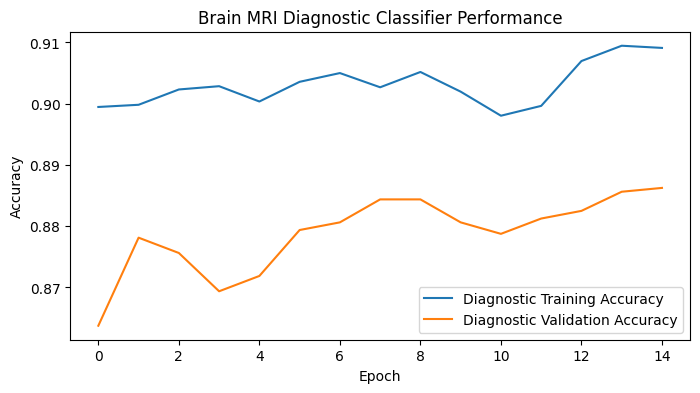

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Diagnostic Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Diagnostic Validation Accuracy')
plt.title('Brain MRI Diagnostic Classifier Performance')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


model.save('brain_tumor_efficientnetb0.keras')

In [17]:
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']
